In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.decomposition import PCA


In [2]:
df = pd.read_csv('data/marketing_campaign.csv', sep='\t')
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [5]:
df = df.dropna()
print("The total number of data points after removing the rows with missing values are:", len(df))

The total number of data points after removing the rows with missing values are: 2216


In [6]:
count_of_mnt_prod = df.loc[:,['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].sum()
avg_of_mnt_prod = df.loc[:,['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].mean()

count_of_num_purchases = df.loc[:,['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum()
avg_of_num_purchases = df.loc[:,['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].mean()

count_of_promotion = df.loc[:,['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']].sum()

C:\Users\abdal\AppData\Local\Temp\ipykernel_18212\252826447.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Education', data=df, ax=axes[0,0], palette=categorical_palette)
C:\Users\abdal\AppData\Local\Temp\ipykernel_18212\252826447.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=45, ha='right')
C:\Users\abdal\AppData\Local\Temp\ipykernel_18212\252826447.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Marital_Status', data=df, ax=axes[0,1], palette=categorical_palette)
C:\Users\abdal\AppData\Local\Temp\ipykernel_18212\252

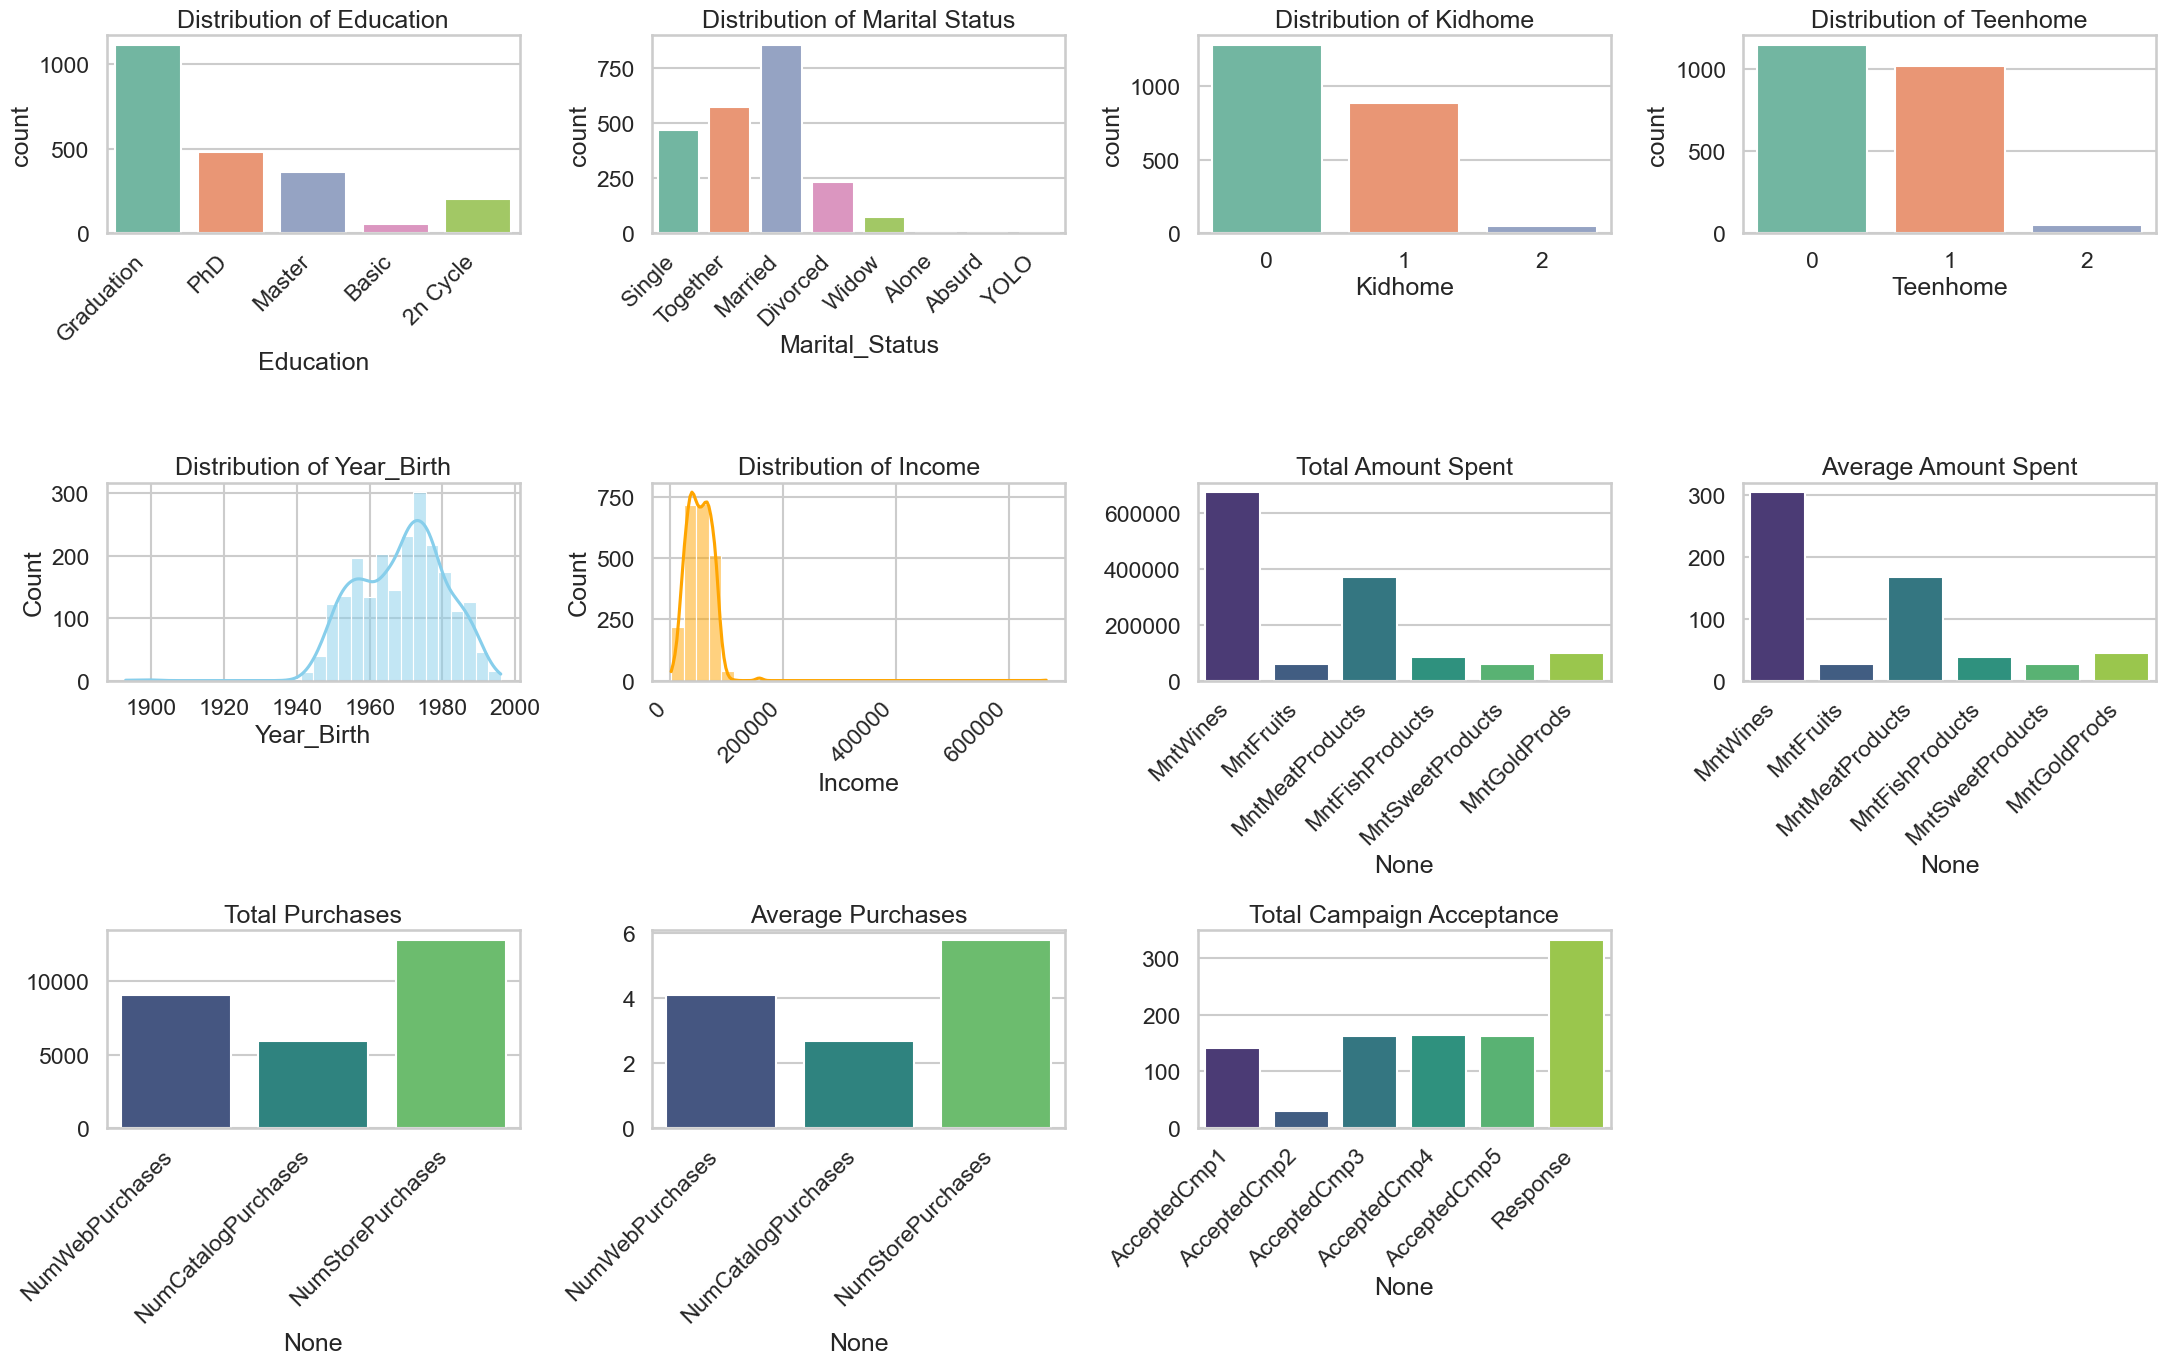

In [7]:
sns.set_style("whitegrid")
sns.set_context("talk")

categorical_palette = "Set2"
numeric_palette = "viridis"

fig, axes = plt.subplots(3, 4, figsize=(22,14))

sns.countplot(x='Education', data=df, ax=axes[0,0], palette=categorical_palette)
axes[0,0].set_title('Distribution of Education')
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=45, ha='right')

sns.countplot(x='Marital_Status', data=df, ax=axes[0,1], palette=categorical_palette)
axes[0,1].set_title('Distribution of Marital Status')
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=45, ha='right')

sns.countplot(x='Kidhome', data=df, ax=axes[0,2], palette=categorical_palette)
axes[0,2].set_title('Distribution of Kidhome')

sns.countplot(x='Teenhome', data=df, ax=axes[0,3], palette=categorical_palette)
axes[0,3].set_title('Distribution of Teenhome')

sns.histplot(df['Year_Birth'], bins=30, kde=True, color='skyblue', ax=axes[1,0])
axes[1,0].set_title('Distribution of Year_Birth')

sns.histplot(df['Income'], bins=30, kde=True, color='orange', ax=axes[1,1])
axes[1,1].set_title('Distribution of Income')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45, ha='right')

sns.barplot(x=count_of_mnt_prod.index, y=count_of_mnt_prod.values, ax=axes[1,2], palette=numeric_palette)
axes[1,2].set_title('Total Amount Spent')
axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=45, ha='right')

sns.barplot(x=avg_of_mnt_prod.index, y=avg_of_mnt_prod.values, ax=axes[1,3], palette=numeric_palette)
axes[1,3].set_title('Average Amount Spent')
axes[1,3].set_xticklabels(axes[1,3].get_xticklabels(), rotation=45, ha='right')

sns.barplot(x=count_of_num_purchases.index, y=count_of_num_purchases.values, ax=axes[2,0], palette=numeric_palette)
axes[2,0].set_title('Total Purchases')
axes[2,0].set_xticklabels(axes[2,0].get_xticklabels(), rotation=45, ha='right')

sns.barplot(x=avg_of_num_purchases.index, y=avg_of_num_purchases.values, ax=axes[2,1], palette=numeric_palette)
axes[2,1].set_title('Average Purchases')
axes[2,1].set_xticklabels(axes[2,1].get_xticklabels(), rotation=45, ha='right')

sns.barplot(x=count_of_promotion.index, y=count_of_promotion.values, ax=axes[2,2], palette=numeric_palette)
axes[2,2].set_title('Total Campaign Acceptance')
axes[2,2].set_xticklabels(axes[2,2].get_xticklabels(), rotation=45, ha='right')

axes[2,3].axis('off')

plt.tight_layout()
plt.show()

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2216.0,5588.353339,3249.376275,0.0,2814.75,5458.5,8421.75,11191.0
Year_Birth,2216.0,1968.820397,11.985554,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2216.0,0.441787,0.536896,0.0,0.00,0.0,1.00,2.0
Teenhome,2216.0,0.505415,0.544181,0.0,0.00,0.0,1.00,2.0
Recency,2216.0,49.012635,28.948352,0.0,24.00,49.0,74.00,99.0
MntWines,2216.0,305.091606,337.327920,0.0,24.00,174.5,505.00,1493.0
MntFruits,2216.0,26.356047,39.793917,0.0,2.00,8.0,33.00,199.0
MntMeatProducts,2216.0,166.995939,224.283273,0.0,16.00,68.0,232.25,1725.0
MntFishProducts,2216.0,37.637635,54.752082,0.0,3.00,12.0,50.00,259.0


In [9]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format = '%d-%m-%Y')
print(df['Dt_Customer'].max())
print(df['Dt_Customer'].min())

2014-06-29 00:00:00
2012-07-30 00:00:00


In [10]:
df['Age'] = 2021 - df['Year_Birth'] 
df['Total_spent'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
partner_map = {
    "Married": 1, "Together": 1,
    "Absurd": 0, "Widow": 0, "YOLO": 0,
    "Divorced": 0, "Single": 0
}
df['Partner'] = df['Marital_Status'].map(partner_map).fillna(0).astype(int)
df['Children'] = df['Kidhome'] + df['Teenhome']
df['Family_size'] = df['Children'] + df['Partner'] + 1
df['Customer_For'] = ((pd.to_datetime('2021-12-31') - df['Dt_Customer']).dt.days).round(1)
df =  df.drop(columns = ["Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2216 non-null   object 
 1   Marital_Status       2216 non-null   object 
 2   Income               2216 non-null   float64
 3   Kidhome              2216 non-null   int64  
 4   Teenhome             2216 non-null   int64  
 5   Recency              2216 non-null   int64  
 6   MntWines             2216 non-null   int64  
 7   MntFruits            2216 non-null   int64  
 8   MntMeatProducts      2216 non-null   int64  
 9   MntFishProducts      2216 non-null   int64  
 10  MntSweetProducts     2216 non-null   int64  
 11  MntGoldProds         2216 non-null   int64  
 12  NumDealsPurchases    2216 non-null   int64  
 13  NumWebPurchases      2216 non-null   int64  
 14  NumCatalogPurchases  2216 non-null   int64  
 15  NumStorePurchases    2216 non-null   int64 

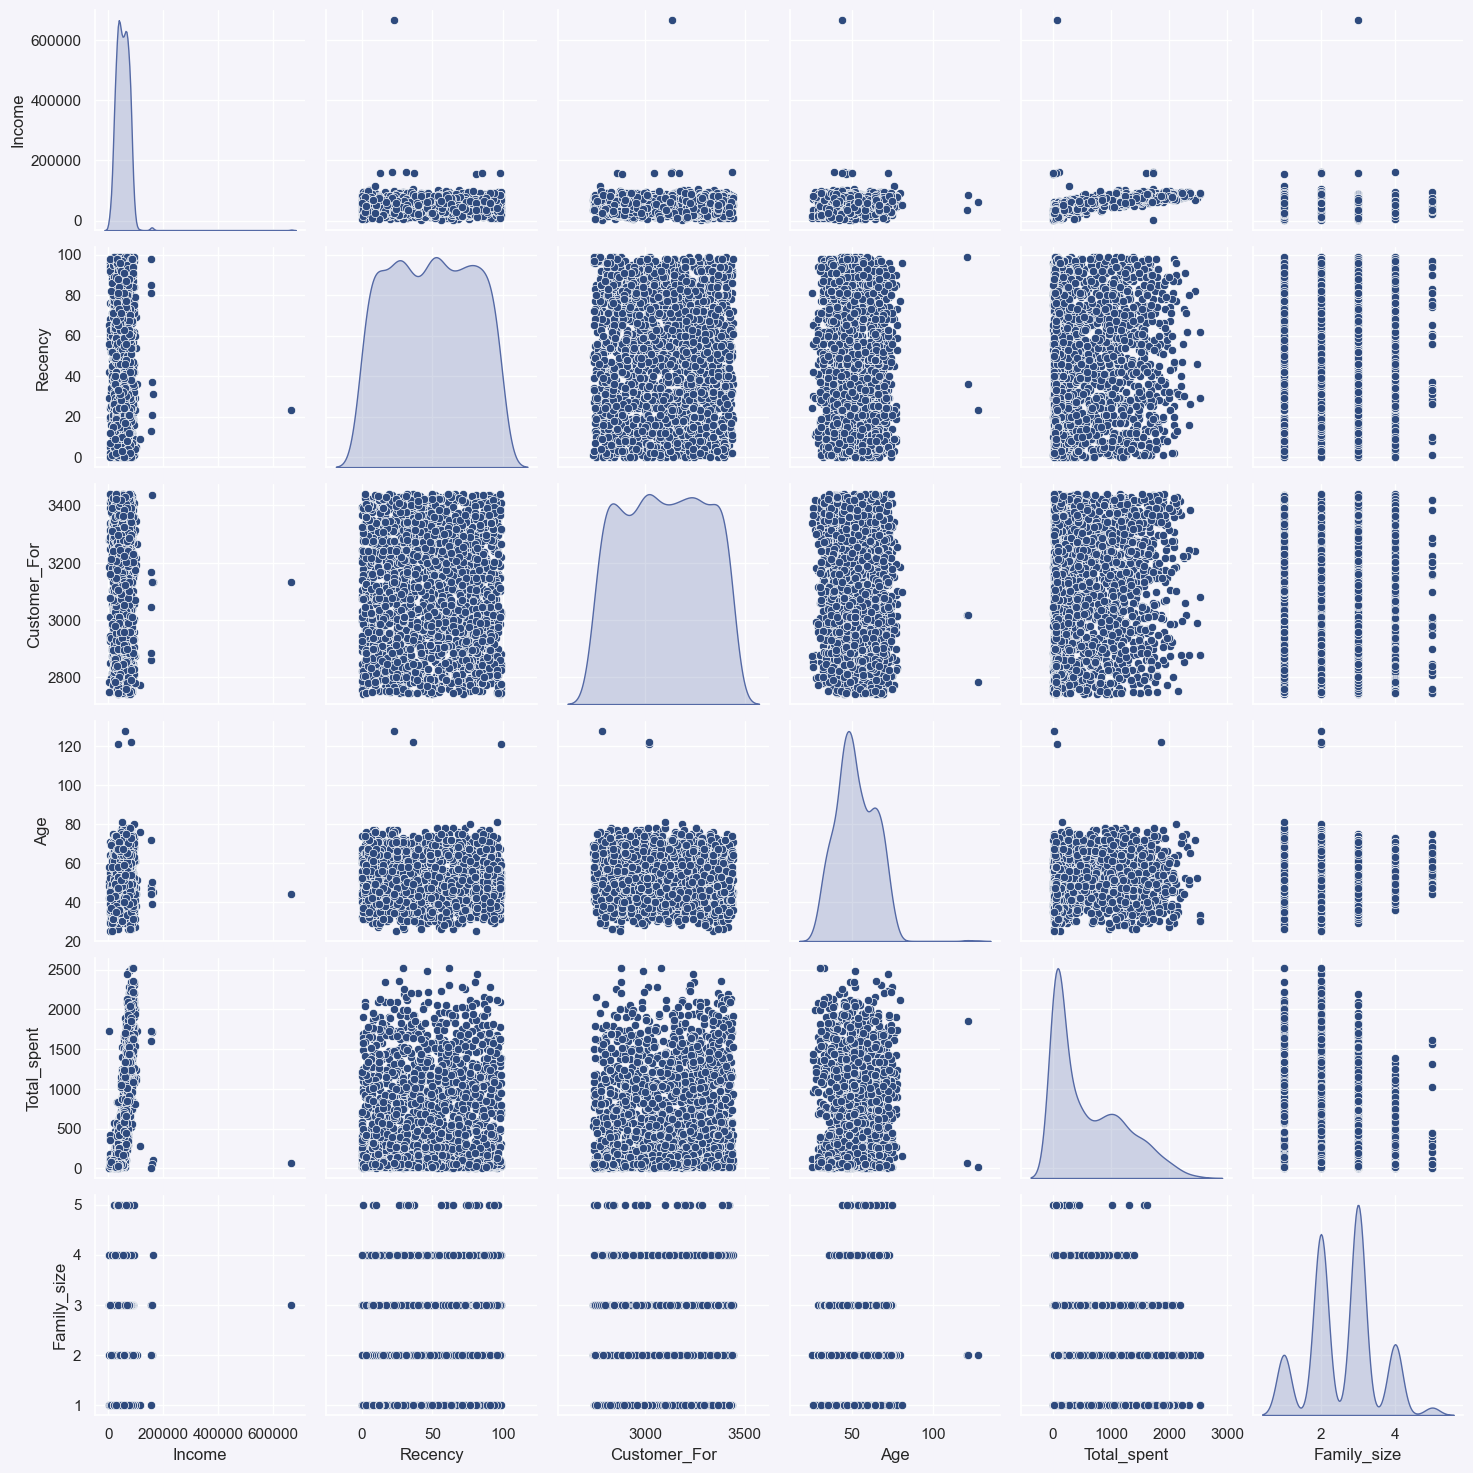

In [11]:
sns.set(rc={"axes.facecolor":"#F5F4FA","figure.facecolor":"#F5F4FA"})
pallet=["#2E4A7D","#5469A5","#7E6BCB","#A36CD0","#D76D82","#B84040"]
sns.pairplot(df[["Income","Recency","Customer_For","Age","Total_spent","Family_size"]],
            diag_kind="kde", plot_kws={"color":pallet[0]}, diag_kws={"color":pallet[1]})
plt.show()

In [12]:
def remove_outliers(data,cols):
    for i in cols:
        q1 = data[i].quantile(0.25)
        q3 = data[i].quantile(0.75)
        iqr = q3 - q1
        upper = q3 + iqr * 1.5
        lower = q1 - iqr * 1.5
        data = data[(data[i] <= upper) & (data[i] >= lower)]
    return data

df = remove_outliers(df,['Age','Income'])
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Income,2205.0,51622.094785,20713.063826,1730.0,35196.0,51287.0,68281.0,113734.0
Kidhome,2205.0,0.442177,0.537132,0.0,0.0,0.0,1.0,2.0
Teenhome,2205.0,0.506576,0.544380,0.0,0.0,0.0,1.0,2.0
Recency,2205.0,49.009070,28.932111,0.0,24.0,49.0,74.0,99.0
MntWines,2205.0,306.164626,337.493839,0.0,24.0,178.0,507.0,1493.0
MntFruits,2205.0,26.403175,39.784484,0.0,2.0,8.0,33.0,199.0
MntMeatProducts,2205.0,165.312018,217.784507,0.0,16.0,68.0,232.0,1725.0
MntFishProducts,2205.0,37.756463,54.824635,0.0,3.0,12.0,50.0,259.0
MntSweetProducts,2205.0,27.128345,41.130468,0.0,1.0,8.0,34.0,262.0
MntGoldProds,2205.0,44.057143,51.736211,0.0,9.0,25.0,56.0,321.0


In [13]:
le = LabelEncoder()
df[['Education','Marital_Status']] = df[['Education','Marital_Status']].apply(le.fit_transform)

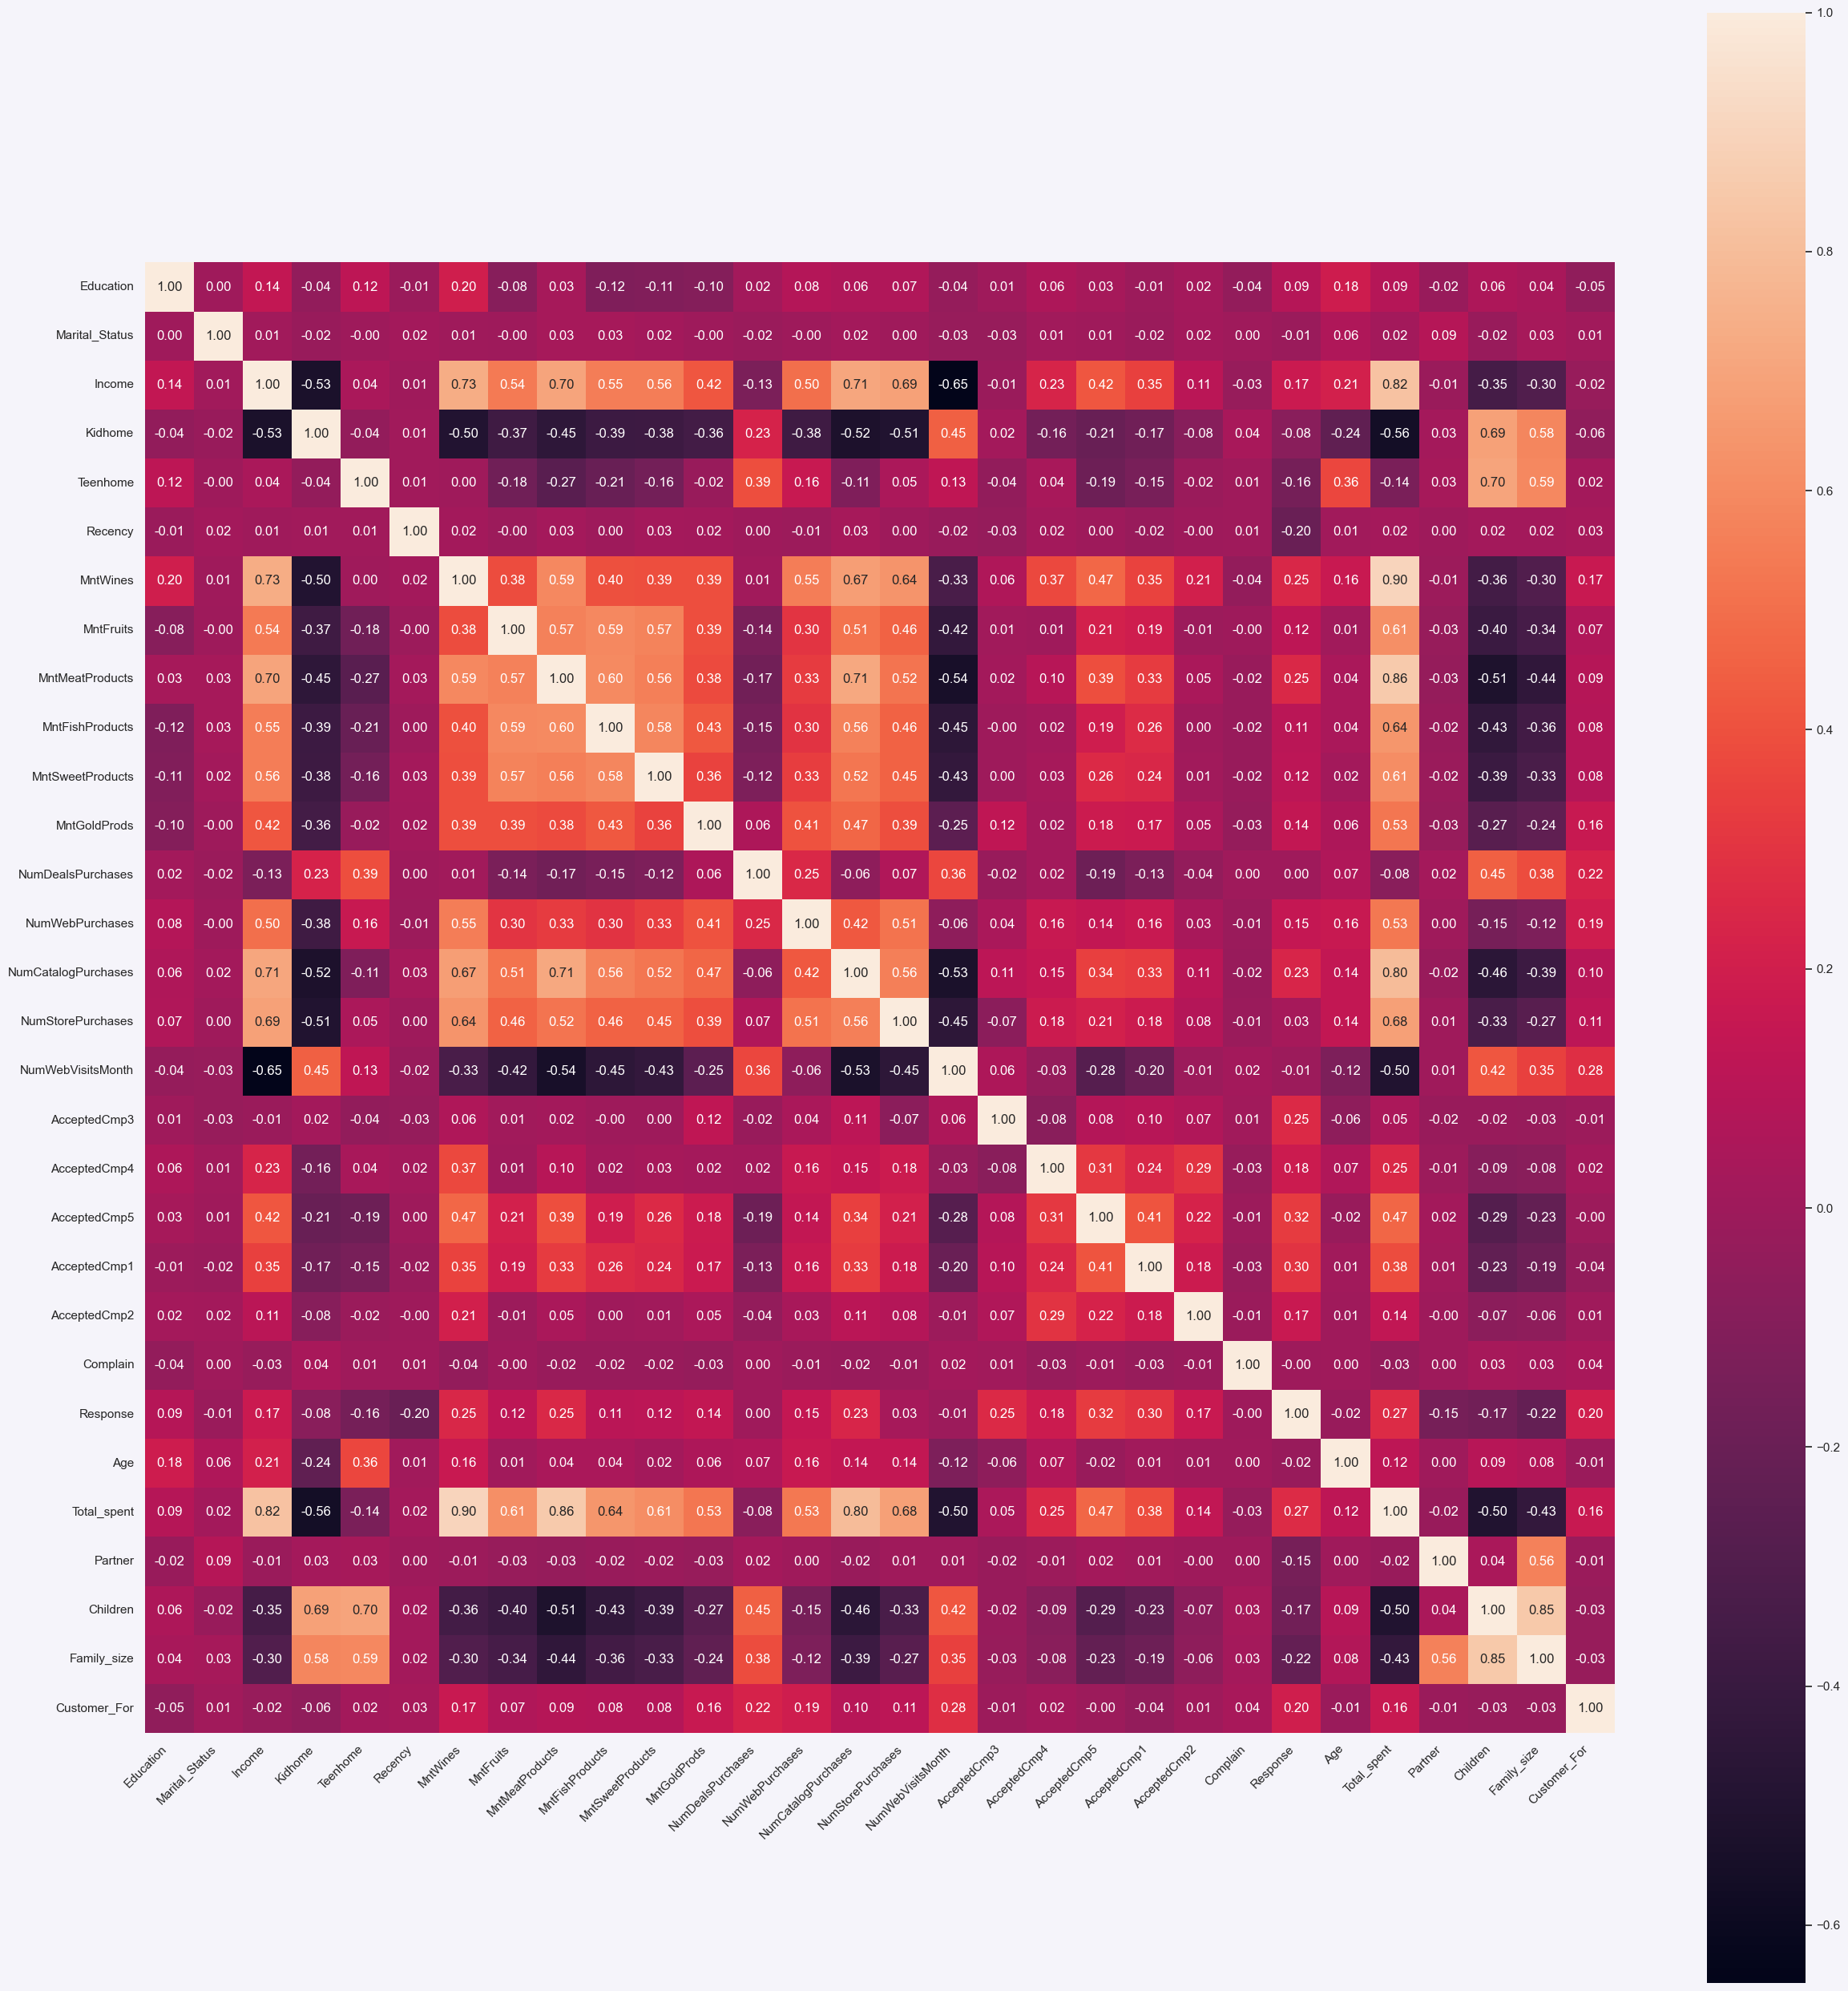

In [14]:
corrmat = df.corr()
plt.figure(figsize=(25,25))
sns.heatmap(corrmat, annot=True, fmt=".2f", square=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
df2 = df.copy()
target_cols = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2', 'Complain', 'Response']
df2 = df2.drop(target_cols,axis = 1)

numerical_features = ["Income","Kidhome","Teenhome","Recency","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds","NumDealsPurchases","NumWebPurchases","NumCatalogPurchases","NumStorePurchases","NumWebVisitsMonth","Age","Total_spent","Children","Family_size","Customer_For"]
categorical_features = ["Education", "Marital_Status", "Partner"]

scaler = StandardScaler()
scaled_numerical = pd.DataFrame(scaler.fit_transform(df2[numerical_features]), columns=numerical_features)
scaled_df = pd.concat([scaled_numerical, df2[categorical_features].reset_index(drop=True)], axis=1)

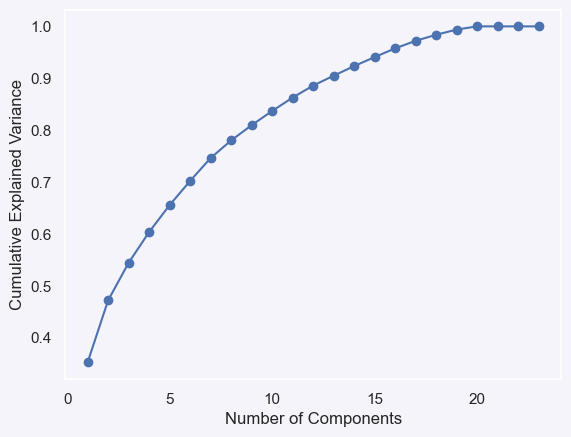

In [16]:
pca = PCA()
pca.fit(scaled_df)

explained = np.cumsum(pca.explained_variance_ratio_)

plt.plot(np.arange(1, len(explained)+1), explained, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()

In [17]:
n_components = np.argmax(explained >= 0.90) + 1
print(n_components)

13


In [18]:
pca = PCA(n_components=n_components)   
pca_df = pd.DataFrame(pca.fit_transform(scaled_df))
pca_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,4.725825,-0.222592,-1.954434,1.030471,0.817544,-0.097759,0.424576,1.770193,0.776983,-0.120286,1.608675,-0.516667,0.778523
1,-2.855387,0.246974,1.326091,-1.501824,0.073189,-0.660060,-0.212042,0.462669,0.004488,0.336512,0.866447,0.010105,0.231362
2,2.288980,-0.700347,0.189539,0.070080,1.238954,-0.806602,-0.987601,-0.647006,-0.007201,-0.848479,-0.083224,-0.685119,-1.192448
3,-2.668882,-1.654560,-0.057643,-0.561948,0.912198,0.778063,-1.225123,-0.967442,0.032618,-0.168892,0.084778,-0.015603,-0.192022
4,-0.457861,0.233590,0.292439,0.114180,-1.014174,2.358876,0.955243,-0.773693,1.082515,-1.106173,0.560992,0.569774,-0.319011


Converged at iteration 19


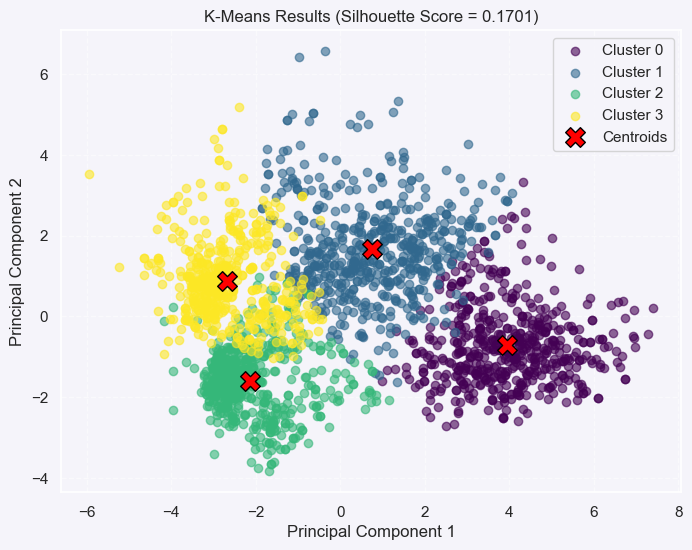

Fitness (Total Cost): 0.17010360412246592


In [19]:
from algorithm.k_mean import KMeans as kmeans
model = kmeans(k=4, max_iters=100, tol=1e-7, random_state=42)
labels , fitness = model.fit(pca_df)
model.plot_clusters(pca_df, labels)
print("Fitness (Total Cost):", fitness)

Converged at iteration 2


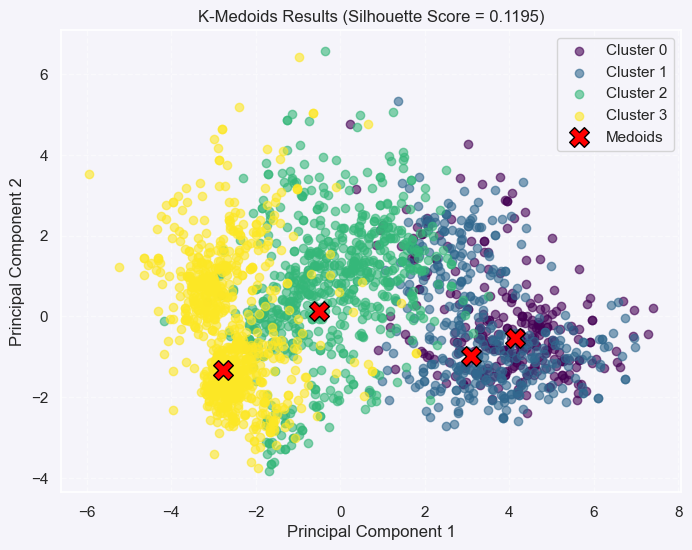

Fitness (Total Cost): 0.11953824486291537


In [20]:
from algorithm.K_Medoids import KMedoids
model = KMedoids(k=4, max_iters=100, tol=1e-7,random_state=42)
labels, fitness = model.fit(pca_df)

model.plot_clusters(pca_df, labels)
print("Fitness (Total Cost):", fitness)

Fitness (Total Cost): 0.13665603111239108


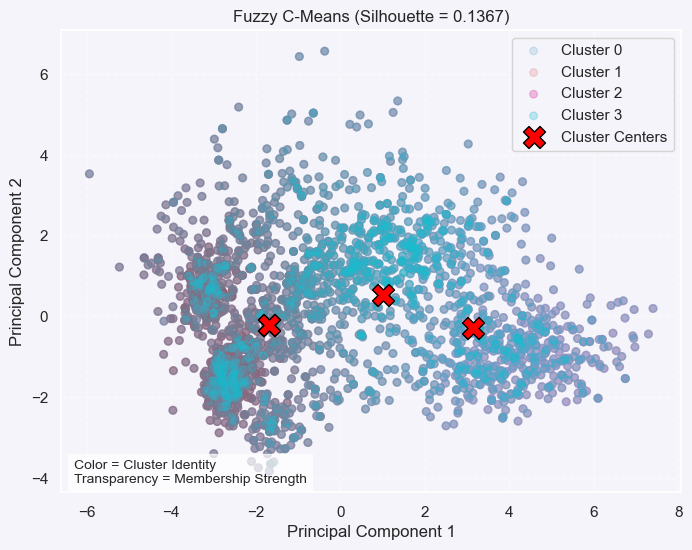

In [21]:
from algorithm.c_means import FuzzyCMeans
model = FuzzyCMeans(k=4, m=2.0, max_iters=100, tol=1e-7, random_state=42)
labels, fitness = model.fit(pca_df)
print("Fitness (Total Cost):", fitness)
model.plot_membership_intensity(pca_df)


EO finished — silhouette: 0.1864


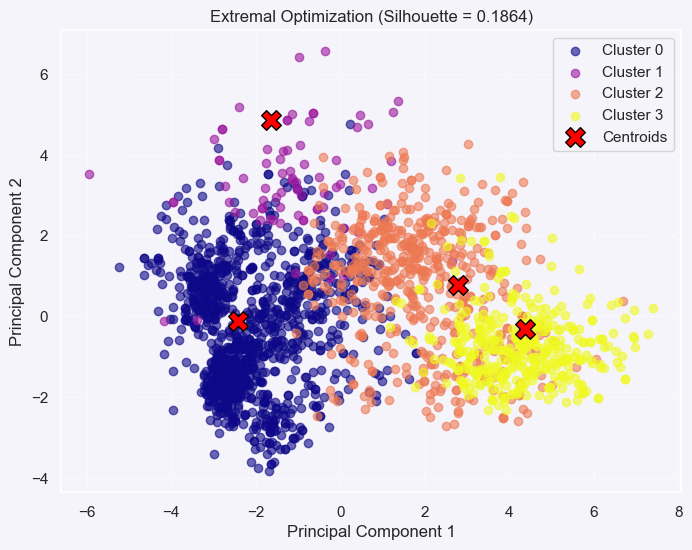

Fitness (Total Cost): 0.18642387896799067


In [22]:
from algorithm.Extremal_Optimization import ExtremalOptimization
model = ExtremalOptimization(k=4, max_iters=100, tau=1.5, perturbation_scale=0.3, random_state=42)
labels, fitness = model.fit(pca_df)
model.plot_clusters(pca_df, labels)
print("Fitness (Total Cost):", fitness)

PSO finished — silhouette: 0.2383
Fitness (Total Cost): 0.2383278100434875


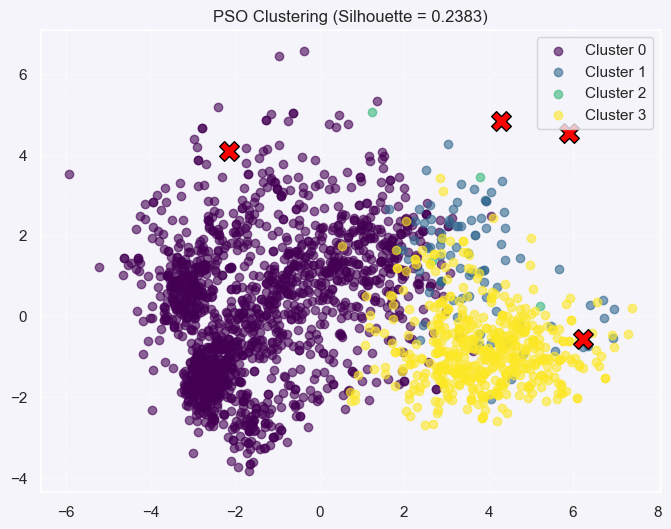

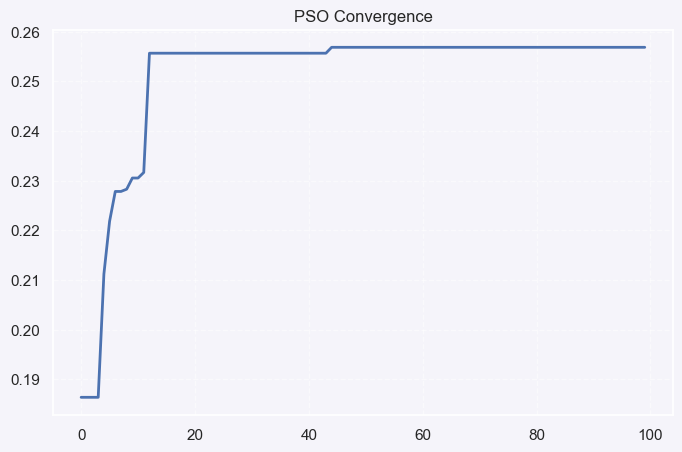

In [24]:
from algorithm.PSO import PSOClustering

pso = PSOClustering(k=4, n_particles=30, max_iters=100, random_state=42)
pso = pso.fit(pca_df)

labels = pso.predict(pca_df)
print("Fitness (Total Cost):", pso.final_fitness)
pso.plot_clusters(pca_df, labels)
pso.plot_convergence()

Found 11 cluster(s), 8 noise point(s), silhouette=-0.3245


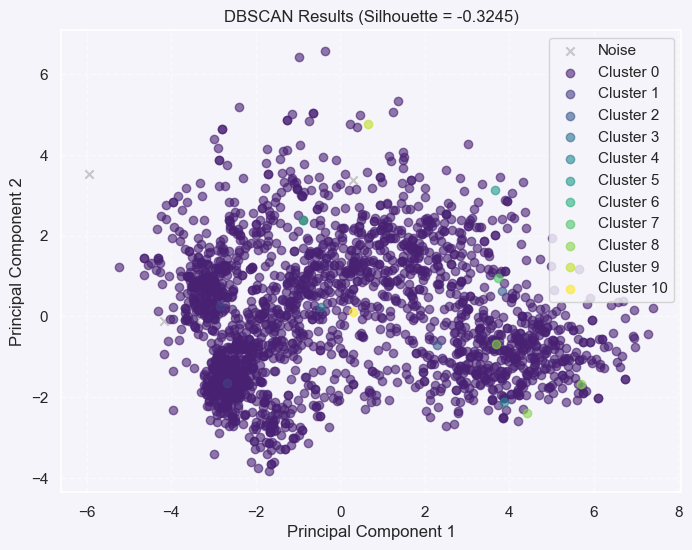

In [25]:
from algorithm.DBSCAN import DBSCAN

model = DBSCAN(eps = 4.6,min_samples=15)
labels = model.fit(pca_df)
model.plot_clusters(pca_df, labels)

Generation 1 | Best Silhouette: 0.2252
Generation 2 | Best Silhouette: 0.2252
Generation 3 | Best Silhouette: 0.2252
Generation 4 | Best Silhouette: 0.2252
Generation 5 | Best Silhouette: 0.2252
Generation 6 | Best Silhouette: 0.2311
Generation 7 | Best Silhouette: 0.2311
Generation 8 | Best Silhouette: 0.2311
Generation 9 | Best Silhouette: 0.2311
Generation 10 | Best Silhouette: 0.2311
Generation 11 | Best Silhouette: 0.2311
Generation 12 | Best Silhouette: 0.2311
Generation 13 | Best Silhouette: 0.2311
Generation 14 | Best Silhouette: 0.2311
Generation 15 | Best Silhouette: 0.2311
Generation 16 | Best Silhouette: 0.2311
Generation 17 | Best Silhouette: 0.2449
Generation 18 | Best Silhouette: 0.2449
Generation 19 | Best Silhouette: 0.2449
Generation 20 | Best Silhouette: 0.2449
Generation 21 | Best Silhouette: 0.2489
Generation 22 | Best Silhouette: 0.2489
Generation 23 | Best Silhouette: 0.2489
Generation 24 | Best Silhouette: 0.2489
Generation 25 | Best Silhouette: 0.2489
Generatio

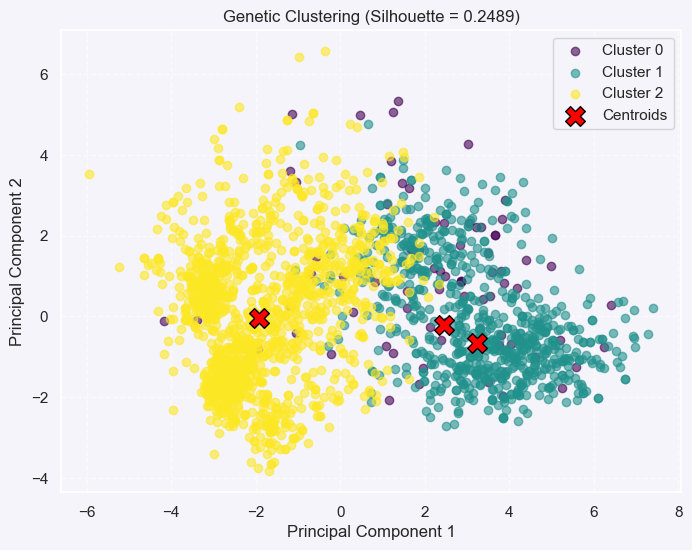

In [26]:
from algorithm.GeneticKmeans import GeneticKMeans

model = GeneticKMeans(
    k=3,
    population_size=20,
    generations=50,
    mutation_rate=0.1,
    random_state=42
)

labels, fitness = model.fit(pca_df)

print("Final Fitness:", fitness)

model.plot_clusters(pca_df, labels)